In [52]:
!pip install pandas
!pip install seaborn

In [53]:
import tensorflow as tf

In [54]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [55]:
import pickle

In [56]:
with open("/Users/gautam/Desktop/Erdos project repo/fall-2025-forecasting-electricity-price/src/data/datasets/data_cleaned.pkl", "rb") as f:
    loaded_dfs=pickle.load(f)

In [57]:
df=loaded_dfs["HI"]

In [58]:
df=df.drop(['WWW'], axis=1)

In [59]:
df

,ALL,ANT,AOR,BIO,BIS,BIT,COL,COW,DFO,DPV,...,WOC,WOO,residential_electricity_price,data_center_employment,coal_price,net_interstate_trade,total_elect_indust,total_international_exports,total_international_imports,total_net_generation
2001-01-01,924.573000,0.0,42.344260,21.098260,6.365,9.867,134.161000,134.161,152.605000,37.249380,...,0.505,48.478000,16.94,439.000000,0.0,0.0,815380.250000,0.0,0.0,886091.250000
2001-02-01,800.847000,0.0,42.729962,20.547330,6.365,9.867,126.097211,130.576,145.423333,37.249380,...,0.505,19.278000,16.73,439.344444,0.0,0.0,815380.250000,0.0,0.0,886091.250000
2001-03-01,827.593292,0.0,43.078338,22.725972,6.365,9.867,118.813789,133.740,138.936667,37.249380,...,0.505,9.410000,16.58,439.655556,0.0,0.0,815380.250000,0.0,0.0,886091.250000
2001-04-01,857.205258,0.0,43.464040,25.138040,6.365,9.867,110.750000,137.243,131.755000,37.249380,...,0.505,0.752000,16.19,440.000000,0.0,0.0,815380.250000,0.0,0.0,886091.250000
2001-05-01,885.862000,0.0,47.772810,28.092810,6.365,9.867,140.633000,140.633,149.117000,37.249380,...,0.505,1.733429,16.30,450.219780,0.0,0.0,815380.250000,0.0,0.0,886091.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-01,749.100190,0.0,174.834860,17.762180,0.000,0.000,0.000000,0.000,85.325100,138.404780,...,0.000,8.616979,41.11,565.000000,0.0,0.0,743937.666667,0.0,0.0,766180.333333
2025-04-01,750.527340,0.0,172.046430,26.158200,0.000,0.000,0.000000,0.000,99.903100,144.508920,...,0.000,13.396170,42.44,565.000000,0.0,0.0,743937.666667,0.0,0.0,766180.333333
2025-05-01,737.154110,0.0,194.037250,19.506830,0.000,0.000,0.000000,0.000,76.228170,152.102380,...,0.000,13.435595,41.03,565.000000,0.0,0.0,743937.666667,0.0,0.0,766180.333333
2025-06-01,774.633257,0.0,195.630503,16.381913,0.000,0.000,0.000000,0.000,96.127304,156.273018,...,0.000,13.476335,40.96,565.000000,0.0,0.0,743937.666667,0.0,0.0,766180.333333


In [60]:
column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

In [61]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

/var/folders/4p/f13_3n_91_b8f3l9jyg_yphh0000gn/T/ipykernel_88365/3214313372.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(df.keys(), rotation=90)


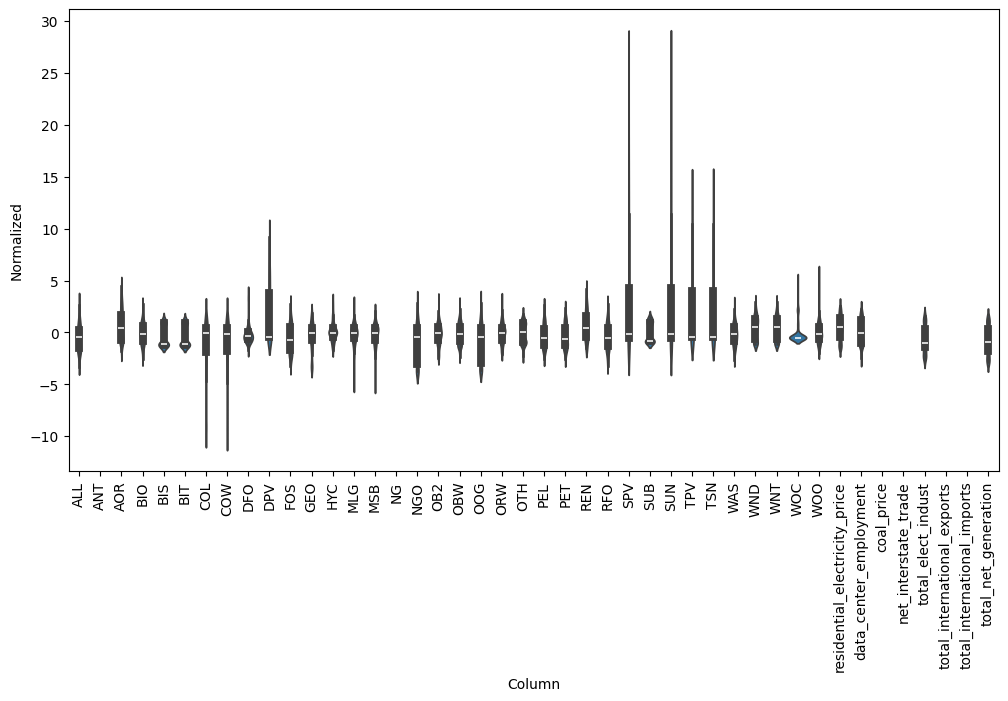

In [62]:
df_std = (df - train_mean) / train_std
df_std = df_std.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(df.keys(), rotation=90)

In [63]:
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])

In [64]:
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

In [65]:
def plot(self, model=None, plot_col='residential_electricity_price', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

In [66]:
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

In [67]:
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.train` dataset
    result = next(iter(self.train))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [68]:
single_step_window = WindowGenerator(
    input_width=1, label_width=1, shift=1,
    label_columns=['residential_electricity_price'])
single_step_window

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['residential_electricity_price']

In [69]:
for example_inputs, example_labels in single_step_window.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 1, 44)
Labels shape (batch, time, features): (32, 1, 1)


2025-10-30 13:46:33.148680: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [70]:
class Baseline(tf.keras.Model):
  def __init__(self, label_index=None):
    super().__init__()
    self.label_index = label_index

  def call(self, inputs):
    if self.label_index is None:
      return inputs
    result = inputs[:, :, self.label_index]
    return result[:, :, tf.newaxis]

In [71]:
baseline = Baseline(label_index=column_indices['residential_electricity_price'])

baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                 metrics=[tf.keras.metrics.MeanAbsoluteError()])

val_performance = {}
performance = {}
val_performance['Baseline'] = baseline.evaluate(single_step_window.val, return_dict=True)
performance['Baseline'] = baseline.evaluate(single_step_window.test, verbose=0, return_dict=True)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0173 - mean_absolute_error: 0.1035 


In [72]:
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1,
    label_columns=['residential_electricity_price'])

wide_window

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['residential_electricity_price']

In [73]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', baseline(wide_window.example[0]).shape)

Input shape: (32, 24, 44)
Output shape: (32, 24, 1)


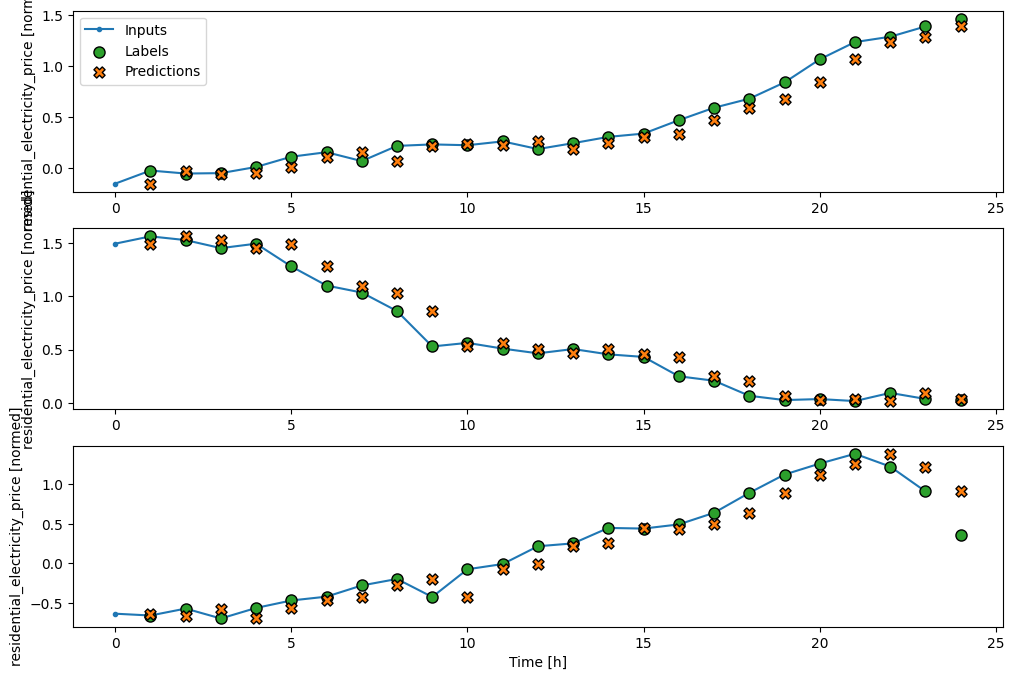

In [74]:
wide_window.plot(baseline)

Recurrent Neural Network

In [75]:
lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
])

In [76]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', lstm_model(wide_window.example[0]).shape)

Input shape: (32, 24, 44)
Output shape: (32, 24, 1)


In [83]:
MAX_EPOCHS = 20

def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

In [84]:
history = compile_and_fit(lstm_model, wide_window)

IPython.display.clear_output()
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val, return_dict=True)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan - mean_absolute_error: nan 


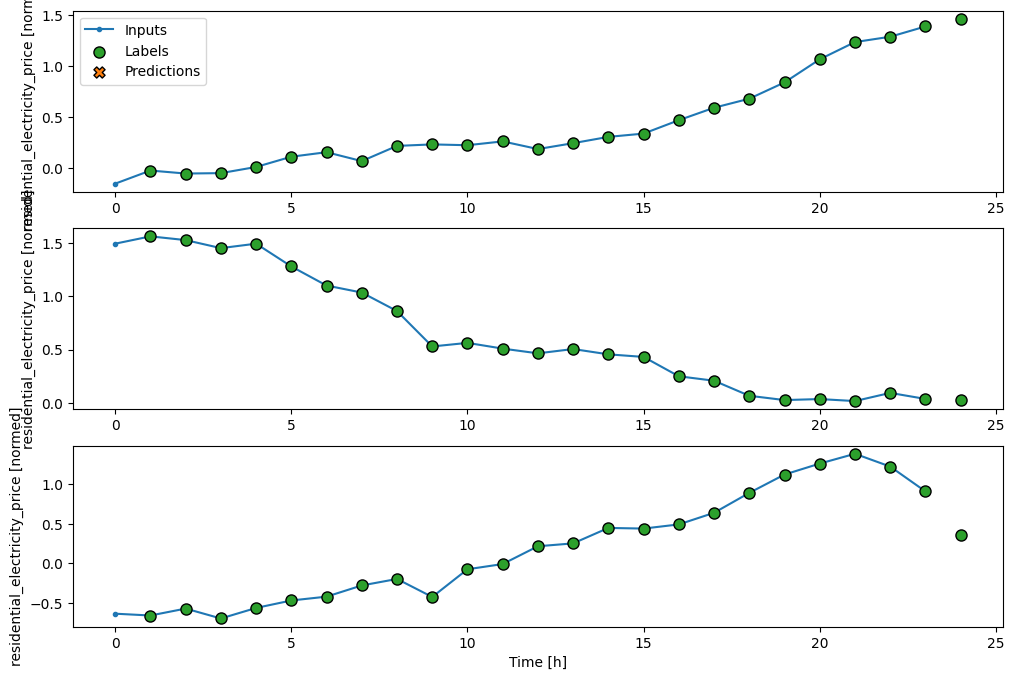

In [79]:
wide_window.plot(lstm_model)

In [80]:
cm = lstm_model.metrics[1]
cm.metrics

[<MeanAbsoluteError name=mean_absolute_error>]

In [82]:
val_performance

{'Baseline': {'loss': 0.017301667481660843,
  'mean_absolute_error': 0.10350114107131958},
 'LSTM': {'loss': nan, 'mean_absolute_error': nan}}